new deformed j_list:
[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

new deformed h_list:
[1, 1, 3/2, 11/6, 53/24, 103/40, 2119/720, 16687/5040, 16481/4480, 1468457/362880, 16019531/3628800, 63633137/13305600, 2467007773/479001600, 34361893981/6227020800, 15549624751/2641766400, 8178130767479/1307674368000, 138547156531409/20922789888000, 92079694567171/13173608448000, 4282366656425369/582033973248000, 72289643288657479/9357315416064000, 6563440628747948887/810967336058880000, 39299278806015611311/4644631106519040000, 9923922230666898717143/1124000727777607680000, 79253545592131482810517/8617338912961658880000, 5934505493938805432851513/620448401733239439360000, 14006262966463963871240459/1410110003939180544000000, 461572649528573755888451011/44810162347400626176000000, 116167945043852116348068366947/10888869450418352160768000000, 3364864615063302680426807870189/304888344611713860501

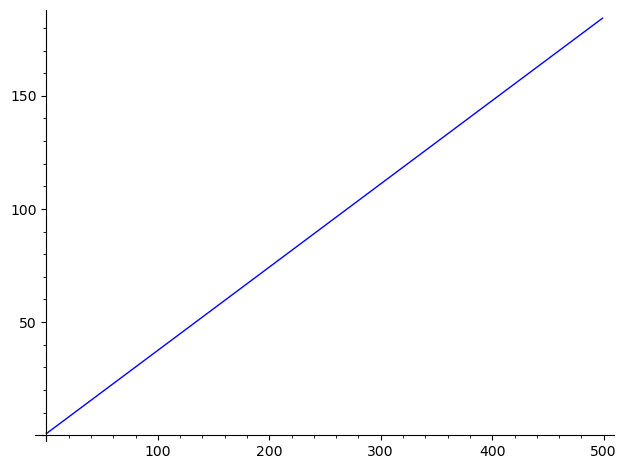

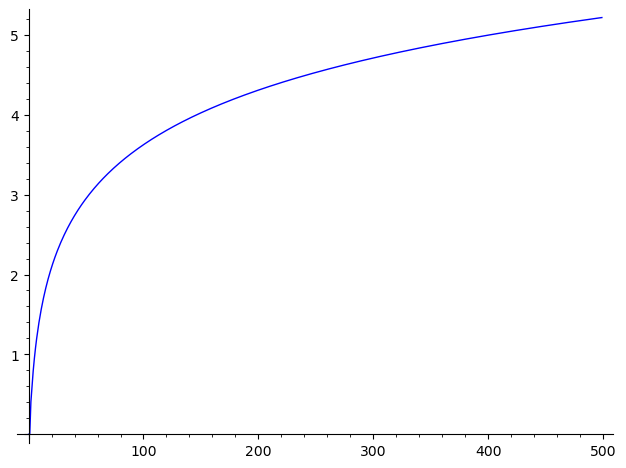

counts: (0, 0)


In [1]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j
    

h_list=[n for n in range(1,500)]
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
print("new deformed j_list:")
print(deformed_j_list[:50])
print()
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("new deformed h_list:")
print(deformed_h_list[:50])
log_data=[]
zero_count=0
negative_count=0
for x in deformed_h_list:
    if x<0:
        negative_count+=1
    if x==0:
        zero_count+=1
    if x!=0:
        log_data.append(log(abs(x)))

p = list_plot(deformed_h_list, plotjoined=True, axes_labels=['', ''])
p.show()

p = list_plot(log_data, plotjoined=True, axes_labels=['', ''])
p.show()
print("counts:",(negative_count,zero_count))

new deformed j_list:
[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
n: 1 elapsed: 0.041624951362609866
n: 1
chi:
x - 1
n: 2 elapsed: 0.041655381520589195
n: 2
chi:
x^2 - 2*x + 3
n: 3 elapsed: 0.04166351954142253
n: 3
chi:
x^3 - 3*x^2 + 9*x - 11
n: 4 elapsed: 0.04167263110478719
n: 4
chi:
x^4 - 4*x^3 + 18*x^2 - 44*x + 53
n: 5 elapsed: 0.041694033145904544
n: 5
chi:
x^5 - 5*x^4 + 30*x^3 - 110*x^2 + 265*x - 309
n: 6 elapsed: 0.041719913482666016
n: 6
chi:
x^6 - 6*x^5 + 45*x^4 - 220*x^3 + 795*x^2 - 1854*x + 2119
n: 7 elapsed: 0.041746115684509276
n: 7
chi:
x^7 - 7*x^6 + 63*x^5 - 385*x^4 + 1855*x^3 - 6489*x^2 + 14833*x - 16687
n: 8 elapsed: 0.041782863934834796
n: 8
chi:
x^8 - 8*x^7 + 84*x^6 - 616*x^5 + 3710*x^4 - 17304*x^3 + 59332*x^2 - 133496*x + 148329
n: 9 elapsed: 0.041842949390411374
n: 9
chi:
x^9 - 9*x^8 + 108*x^7 - 924*x^6 + 6678*x^5 - 38934*x^4 + 177996*x^3 - 600732*x^2 + 1334961

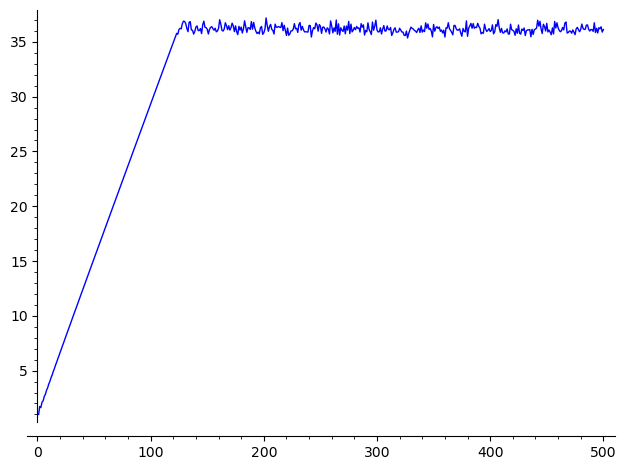

In [4]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

import matplotlib.pyplot as plt
import numpy as np

def signsNoGraphics(f, center, searchradius, grain):
    inc = searchradius / grain
    dta = []

    black = (0, 0, 0)
    green = (0, 1, 0)
    blue = (0, 0, 1)
    red = (1, 0, 0)
    yellow = (1, 1, 0)

    k = -searchradius - inc
    while k < searchradius:
        row = []
        j = -searchradius - inc
        while j < searchradius:
            w = CC(center + j + k * I)
            fw = f(w)
            u = real_part(fw)
            v = imag_part(fw)

            if u >= 0:
                if v >= 0:
                    shade = blue
                else:
                    shade = green
            else:
                if v >= 0:
                    shade = red
                else:
                    shade = yellow

            row.append(shade)
            j += inc
        dta.append(row)
        k += inc

    return dta

def plot_signs(dta):
    img = np.array(dta, dtype=float)
    plt.figure(figsize=(8, 8))
    plt.imshow(img, origin='lower', interpolation='nearest')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


h_list=[n for n in range(1,521)]
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("new deformed j_list:")
print(deformed_j_list[:50])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
    if n<21:
            print("n:",n)
            print("chi:")
            print(chi)
    
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()


chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run21may26no9.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run21may26no10.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run21may26no11.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run21may26no12.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run21may26no12a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run21may26no12b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run21may26no12c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run21may26no12d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run21may26no12e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)